# TabPFN NTO Investigation: Features, Precision & Multi-label

This notebook investigates three aspects of TabPFN-based Network Topology Optimization (NTO):

1. **Feature Analysis** — Are the features standard for NTO? What drives predictions?
2. **Improving Precision** — Address the low precision (~32%) for "good" action classification
3. **Multi-label Classification** — Move beyond binary to multiple action quality levels

Constraints: max 1K training samples, no agent simulation, CPU only.

## 1. Setup & Data Collection

In [1]:
import grid2op
from grid2op.Action import TopologyAction
from grid2op.Agent import DoNothingAgent
from grid2op.Parameters import Parameters
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')
import os
os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"

try:
    from lightsim2grid import LightSimBackend
    backend = LightSimBackend()
    print("Using LightSimBackend")
except ImportError:
    backend = None
    print("Using default backend")

print(f"grid2op version: {grid2op.__version__}")

Using LightSimBackend
grid2op version: 1.12.3


In [2]:
# Create environment
env_name = "l2rpn_case14_sandbox"
param = Parameters()
param.NO_OVERFLOW_DISCONNECTION = False

env = grid2op.make(
    env_name,
    param=param,
    backend=LightSimBackend() if backend is not None else None,
    action_class=TopologyAction,
)
print(f"Env: {env_name}")
print(f"  Substations: {env.n_sub}, Lines: {env.n_line}")
print(f"  Generators: {env.n_gen}, Loads: {env.n_load}")
print(f"  Topo vector size: {env.dim_topo}")

# Get all unitary topology actions
do_nothing_action = env.action_space({})
all_topo_actions = env.action_space.get_all_unitary_topologies_set(env.action_space)
print(f"  Total unitary topo actions: {len(all_topo_actions)}")

# Subsample to 100 candidate actions
MAX_ACTIONS = 100
candidate_actions = [do_nothing_action]
for act in all_topo_actions:
    candidate_actions.append(act)

if len(candidate_actions) > MAX_ACTIONS:
    rng_act = np.random.RandomState(42)
    sampled_idx = rng_act.choice(range(1, len(candidate_actions)), MAX_ACTIONS - 1, replace=False)
    candidate_actions = [candidate_actions[0]] + [candidate_actions[i] for i in sampled_idx]

print(f"  Using {len(candidate_actions)} candidate actions")

Env: l2rpn_case14_sandbox
  Substations: 14, Lines: 20
  Generators: 6, Loads: 11
  Topo vector size: 57
  Total unitary topo actions: 178
  Using 100 candidate actions


In [3]:
# Feature extraction — with clear categorization for NTO analysis
def extract_obs_features(obs):
    """Extract features from grid2op observation, categorized by type."""
    features = {}
    
    # === Category 1: Line Loading (rho) — THE key NTO indicator ===
    for i in range(obs.n_line):
        features[f'rho_{i}'] = obs.rho[i]
    features['rho_max'] = obs.rho.max()
    features['rho_mean'] = obs.rho.mean()
    features['rho_std'] = obs.rho.std()
    features['n_overloaded'] = int((obs.rho > 1.0).sum())
    
    # === Category 2: Generator power (normalized) ===
    gen_pmax = obs.gen_pmax.copy()
    gen_pmax[gen_pmax == 0] = 1.0
    for i in range(obs.n_gen):
        features[f'gen_p_norm_{i}'] = obs.gen_p[i] / gen_pmax[i]
    
    # === Category 3: Load power (fractional) ===
    total_load = obs.load_p.sum() if obs.load_p.sum() > 0 else 1.0
    for i in range(obs.n_load):
        features[f'load_p_frac_{i}'] = obs.load_p[i] / total_load
    
    # === Category 4: Voltage ===
    features['v_or_mean'] = obs.v_or.mean() if hasattr(obs, 'v_or') else 1.0
    features['v_or_std'] = obs.v_or.std() if hasattr(obs, 'v_or') else 0.0
    for i in range(obs.n_line):
        features[f'v_or_{i}'] = obs.v_or[i]
        features[f'v_ex_{i}'] = obs.v_ex[i]
    
    # === Category 5: Topology state ===
    for i in range(len(obs.topo_vect)):
        features[f'topo_{i}'] = obs.topo_vect[i]
    
    # === Category 6: Line status ===
    for i in range(obs.n_line):
        features[f'line_status_{i}'] = int(obs.line_status[i])
    
    # === Category 7: Active/reactive power flows ===
    for i in range(obs.n_line):
        features[f'p_or_{i}'] = obs.p_or[i]
        features[f'q_or_{i}'] = obs.q_or[i]
    
    # === Category 8: Time features ===
    features['hour'] = obs.hour_of_day
    features['day'] = obs.day_of_week
    
    return features


def encode_action(action, env):
    """Encode topology action as feature vector."""
    feats = {}
    set_bus = action.set_bus
    change_bus = action.change_bus
    
    affected_sub = -1
    for sub_id in range(env.n_sub):
        start = int(np.sum(env.sub_info[:sub_id]))
        end = start + env.sub_info[sub_id]
        if np.any(set_bus[start:end] != 0) or np.any(change_bus[start:end]):
            affected_sub = sub_id
            break
    
    feats['affected_sub'] = affected_sub
    feats['n_elements_changed'] = int(np.sum(set_bus != 0)) + int(np.sum(change_bus))
    feats['is_do_nothing'] = 1 if (np.all(set_bus == 0) and np.all(~change_bus)) else 0
    
    if affected_sub >= 0:
        start = int(np.sum(env.sub_info[:affected_sub]))
        end = start + env.sub_info[affected_sub]
        sub_bus = set_bus[start:end]
        feats['sub_size'] = env.sub_info[affected_sub]
        feats['n_on_bus2'] = int(np.sum(sub_bus == 2))
        feats['frac_on_bus2'] = feats['n_on_bus2'] / max(feats['sub_size'], 1)
    else:
        feats['sub_size'] = 0
        feats['n_on_bus2'] = 0
        feats['frac_on_bus2'] = 0.0
    
    return feats


def evaluate_action(obs, action, do_nothing_reward):
    """Simulate an action and return quality metrics."""
    try:
        sim_obs, sim_reward, sim_done, sim_info = obs.simulate(action)
        if sim_done:
            return {'reward': -100, 'survived': False, 'max_rho': 2.0,
                    'reward_gain': -100 - do_nothing_reward}
        return {
            'reward': sim_reward,
            'survived': True,
            'max_rho': sim_obs.rho.max(),
            'reward_gain': sim_reward - do_nothing_reward
        }
    except Exception:
        return {'reward': -100, 'survived': False, 'max_rho': 2.0,
                'reward_gain': -100 - do_nothing_reward}


# Pre-compute action features
action_feature_list = []
for act_idx, action in enumerate(candidate_actions):
    af = encode_action(action, env)
    af['action_idx'] = act_idx
    action_feature_list.append(af)
action_features_df = pd.DataFrame(action_feature_list)

print(f"Features defined. Action features: {list(action_features_df.columns)}")

Features defined. Action features: ['affected_sub', 'n_elements_changed', 'is_do_nothing', 'sub_size', 'n_on_bus2', 'frac_on_bus2', 'action_idx']


In [4]:
# Collect data
N_EPISODES = 3
STEPS_PER_EPISODE = 50
all_rows = []

for ep in range(N_EPISODES):
    obs = env.reset()
    for step in range(STEPS_PER_EPISODE):
        obs_features = extract_obs_features(obs)
        dn_result = evaluate_action(obs, do_nothing_action, 0)
        dn_reward = dn_result['reward']
        
        for act_idx, action in enumerate(candidate_actions):
            result = evaluate_action(obs, action, dn_reward)
            row = obs_features.copy()
            row['action_idx'] = act_idx
            row['sim_reward'] = result['reward']
            row['sim_survived'] = result['survived']
            row['sim_max_rho'] = result['max_rho']
            row['reward_gain'] = result['reward_gain']
            row['episode'] = ep
            row['step'] = step
            all_rows.append(row)
        
        obs, reward, done, info = env.step(do_nothing_action)
        if done:
            break
    print(f"Episode {ep+1}/{N_EPISODES} done: {step+1} steps")

df = pd.DataFrame(all_rows)
print(f"\nTotal data points: {len(df)}")
print(f"Columns: {len(df.columns)}")

Episode 1/3 done: 50 steps
Episode 2/3 done: 50 steps
Episode 3/3 done: 3 steps

Total data points: 10300
Columns: 209


In [5]:
# Merge action features and create labels
df = df.merge(action_features_df, on='action_idx', how='left')

# Do-nothing baseline per (episode, step)
dn_rows = df[df['action_idx'] == 0][['episode', 'step', 'sim_max_rho']].rename(
    columns={'sim_max_rho': 'dn_max_rho'})
if 'dn_max_rho' in df.columns:
    df = df.drop(columns=['dn_max_rho'])
df = df.merge(dn_rows, on=['episode', 'step'], how='left')

# Binary label: good = survived AND (better reward OR lower max_rho)
df['label_binary'] = ((df['sim_survived']) & 
                       ((df['reward_gain'] > 0) | (df['sim_max_rho'] < df['dn_max_rho']))).astype(int)

# Multi-label: 4 quality levels
def assign_multi_label(row):
    if not row['sim_survived']:
        return 0  # Bad: action caused failure
    if row['reward_gain'] <= 0 and row['sim_max_rho'] >= row['dn_max_rho']:
        return 1  # Neutral: survived but no improvement
    if row['sim_max_rho'] < row['dn_max_rho'] and row['reward_gain'] > 0:
        return 3  # Excellent: both rho reduction AND reward gain
    return 2  # Good: some improvement (either rho reduction or reward gain)

df['label_multi'] = df.apply(assign_multi_label, axis=1)

print("Binary label distribution:")
print(df['label_binary'].value_counts().sort_index())
print(f"\nMulti-label distribution:")
print(df['label_multi'].value_counts().sort_index())
print("  0=Bad (failed), 1=Neutral, 2=Good, 3=Excellent")

# Identify feature categories
meta_cols = ['action_idx', 'sim_reward', 'sim_survived', 'sim_max_rho', 
             'reward_gain', 'episode', 'step', 'label_binary', 'label_multi', 'dn_max_rho']
feature_cols = [c for c in df.columns if c not in meta_cols]

# Categorize features
cat_rho = [c for c in feature_cols if c.startswith('rho_') or c in ['rho_max','rho_mean','rho_std','n_overloaded']]
cat_gen = [c for c in feature_cols if c.startswith('gen_p_norm')]
cat_load = [c for c in feature_cols if c.startswith('load_p_frac')]
cat_voltage = [c for c in feature_cols if c.startswith('v_or') or c.startswith('v_ex') or c in ['v_or_mean','v_or_std']]
cat_topo = [c for c in feature_cols if c.startswith('topo_')]
cat_line_status = [c for c in feature_cols if c.startswith('line_status')]
cat_power_flow = [c for c in feature_cols if c.startswith('p_or') or c.startswith('q_or')]
cat_time = [c for c in feature_cols if c in ['hour', 'day']]
cat_action = [c for c in feature_cols if c in ['affected_sub','n_elements_changed','is_do_nothing','sub_size','n_on_bus2','frac_on_bus2']]

print(f"\nFeature categories:")
print(f"  Line loading (rho):  {len(cat_rho)}")
print(f"  Generator power:     {len(cat_gen)}")
print(f"  Load power:          {len(cat_load)}")
print(f"  Voltage:             {len(cat_voltage)}")
print(f"  Topology state:      {len(cat_topo)}")
print(f"  Line status:         {len(cat_line_status)}")
print(f"  Power flows (P,Q):   {len(cat_power_flow)}")
print(f"  Time:                {len(cat_time)}")
print(f"  Action encoding:     {len(cat_action)}")
print(f"  TOTAL:               {len(feature_cols)}")

Binary label distribution:
label_binary
0    8595
1    1705
Name: count, dtype: int64

Multi-label distribution:
label_multi
0    1055
1    7540
2    1390
3     315
Name: count, dtype: int64
  0=Bad (failed), 1=Neutral, 2=Good, 3=Excellent

Feature categories:
  Line loading (rho):  24
  Generator power:     6
  Load power:          11
  Voltage:             42
  Topology state:      57
  Line status:         20
  Power flows (P,Q):   40
  Time:                2
  Action encoding:     6
  TOTAL:               208


## 2. Feature Analysis

### Standard NTO features in literature:
- **Line loading (ρ)**: The primary indicator — ratio of current flow to thermal limit. This is what NTO aims to reduce.
- **Bus voltages**: Voltage magnitudes at substations, affected by topology changes.
- **Power injections**: Generator output and load demand — define the power flow problem.
- **Topology state**: Current bus assignments — the decision variable in NTO.
- **Power flows (P, Q)**: Active and reactive power on each line.
- **Line status**: Which lines are connected/disconnected.
- **Time features**: Hour/day capture demand patterns and generation profiles.

Our features cover all standard categories. We additionally encode **action features** (which substation, how many elements changed) which is non-standard but natural for a classification formulation.

In [6]:
# Train/test split
train_mask = df['episode'].isin([0, 1])
test_mask = df['episode'] == 2

X = df[feature_cols].values.astype(np.float32)
y_bin = df['label_binary'].values.astype(int)
y_multi = df['label_multi'].values.astype(int)

X_train, y_train_bin = X[train_mask.values], y_bin[train_mask.values]
X_test, y_test_bin = X[test_mask.values], y_bin[test_mask.values]
y_train_multi = y_multi[train_mask.values]
y_test_multi = y_multi[test_mask.values]

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Features: {X_train.shape[1]}")

Train: 10000, Test: 300
Features: 208


In [7]:
# Feature importance via category ablation
# Train a baseline TabPFN, then retrain removing each feature category
from tabpfn import TabPFNClassifier

# Balance and subsample to 1K
rng = np.random.RandomState(42)
pos_idx = np.where(y_train_bin == 1)[0]
neg_idx = np.where(y_train_bin == 0)[0]
n_pos = len(pos_idx)
neg_sampled = rng.choice(neg_idx, n_pos, replace=False)
balanced_idx = np.concatenate([pos_idx, neg_sampled])
rng.shuffle(balanced_idx)

MAX_TRAIN = 1000
if len(balanced_idx) > MAX_TRAIN:
    balanced_idx = rng.choice(balanced_idx, MAX_TRAIN, replace=False)

X_train_bal = X_train[balanced_idx]
y_train_bal = y_train_bin[balanced_idx]
print(f"Balanced training: {len(X_train_bal)} samples")

# Limit to top 100 features by variance
MAX_FEATURES = 100
if X_train_bal.shape[1] > MAX_FEATURES:
    variances = np.var(X_train_bal, axis=0)
    top_feat_idx = np.argsort(variances)[-MAX_FEATURES:]
    X_train_sub = X_train_bal[:, top_feat_idx]
    X_test_sub = X_test[:, top_feat_idx]
    selected_features = [feature_cols[i] for i in top_feat_idx]
    print(f"Selected top {MAX_FEATURES} features by variance")
else:
    X_train_sub = X_train_bal
    X_test_sub = X_test
    selected_features = feature_cols
    top_feat_idx = None

# Baseline TabPFN
tabpfn = TabPFNClassifier(device='cpu', ignore_pretraining_limits=True)
tabpfn.fit(X_train_sub, y_train_bal)
y_pred = tabpfn.predict(X_test_sub)
y_prob = tabpfn.predict_proba(X_test_sub)

print(f"\nBaseline (all features):")
print(f"  Accuracy:  {accuracy_score(y_test_bin, y_pred):.3f}")
print(f"  Precision: {precision_score(y_test_bin, y_pred, zero_division=0):.3f}")
print(f"  Recall:    {recall_score(y_test_bin, y_pred, zero_division=0):.3f}")
print(f"  F1:        {f1_score(y_test_bin, y_pred, zero_division=0):.3f}")
if len(np.unique(y_test_bin)) > 1:
    print(f"  ROC AUC:   {roc_auc_score(y_test_bin, y_prob[:, 1]):.3f}")

Balanced training: 1000 samples
Selected top 100 features by variance

Baseline (all features):
  Accuracy:  0.723
  Precision: 0.390
  Recall:    0.683
  F1:        0.497
  ROC AUC:   0.786


In [8]:
# Category ablation: remove each feature group and measure impact
categories = {
    'Line Loading (ρ)': cat_rho,
    'Generator Power': cat_gen,
    'Load Power': cat_load,
    'Voltage': cat_voltage,
    'Topology State': cat_topo,
    'Line Status': cat_line_status,
    'Power Flows (P,Q)': cat_power_flow,
    'Time': cat_time,
    'Action Encoding': cat_action,
}

ablation_results = []
for cat_name, cat_cols in categories.items():
    # Get indices of features NOT in this category (among selected features)
    keep_cols = [i for i, f in enumerate(selected_features) if f not in cat_cols]
    if len(keep_cols) == 0 or len(keep_cols) == len(selected_features):
        print(f"  {cat_name}: skipped (no overlap with selected features)")
        ablation_results.append({'Category': cat_name, 'F1': np.nan, 'AUC': np.nan, 'Precision': np.nan})
        continue
    
    X_train_abl = X_train_sub[:, keep_cols]
    X_test_abl = X_test_sub[:, keep_cols]
    
    tabpfn_abl = TabPFNClassifier(device='cpu', ignore_pretraining_limits=True)
    tabpfn_abl.fit(X_train_abl, y_train_bal)
    y_pred_abl = tabpfn_abl.predict(X_test_abl)
    y_prob_abl = tabpfn_abl.predict_proba(X_test_abl)
    
    f1_abl = f1_score(y_test_bin, y_pred_abl, zero_division=0)
    prec_abl = precision_score(y_test_bin, y_pred_abl, zero_division=0)
    auc_abl = roc_auc_score(y_test_bin, y_prob_abl[:, 1]) if len(np.unique(y_test_bin)) > 1 else np.nan
    
    n_removed = len(selected_features) - len(keep_cols)
    print(f"  Without {cat_name} (-{n_removed} feats): F1={f1_abl:.3f}, AUC={auc_abl:.3f}, Prec={prec_abl:.3f}")
    ablation_results.append({'Category': cat_name, 'F1': f1_abl, 'AUC': auc_abl, 'Precision': prec_abl})

abl_df = pd.DataFrame(ablation_results)

  Without Line Loading (ρ) (-21 feats): F1=0.497, AUC=0.784, Prec=0.390
  Without Generator Power (-4 feats): F1=0.497, AUC=0.773, Prec=0.390
  Load Power: skipped (no overlap with selected features)
  Without Voltage (-29 feats): F1=0.497, AUC=0.761, Prec=0.390
  Topology State: skipped (no overlap with selected features)
  Line Status: skipped (no overlap with selected features)
  Without Power Flows (P,Q) (-39 feats): F1=0.497, AUC=0.758, Prec=0.390
  Without Time (-1 feats): F1=0.497, AUC=0.791, Prec=0.390
  Without Action Encoding (-6 feats): F1=0.338, AUC=0.582, Prec=0.220


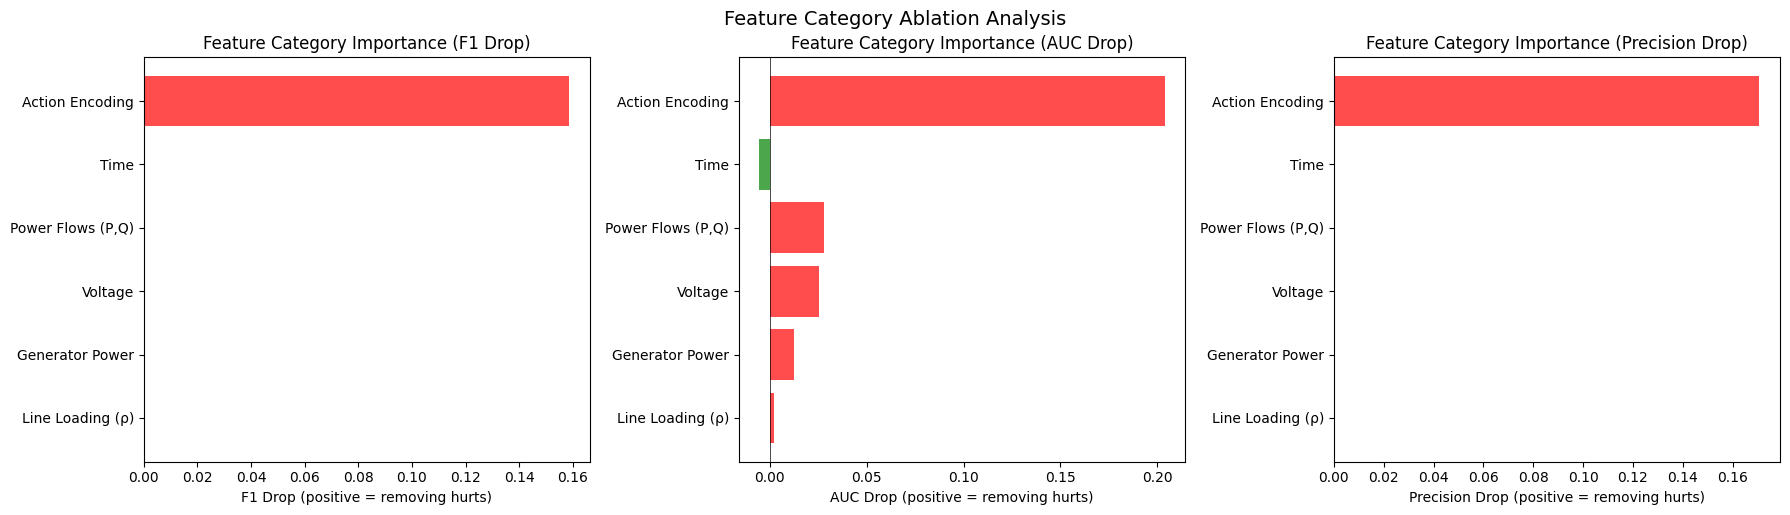


Ablation Summary:
         Category       F1      AUC  Precision  F1_drop  AUC_drop
 Line Loading (ρ) 0.496970 0.783958   0.390476 0.000000  0.002083
  Generator Power 0.496970 0.773403   0.390476 0.000000  0.012639
          Voltage 0.496970 0.760590   0.390476 0.000000  0.025451
Power Flows (P,Q) 0.496970 0.758229   0.390476 0.000000  0.027812
             Time 0.496970 0.791493   0.390476 0.000000 -0.005451
  Action Encoding 0.338462 0.582222   0.220000 0.158508  0.203819


In [9]:
# Visualize feature importance (drop in metric when category removed)
baseline_f1 = f1_score(y_test_bin, y_pred, zero_division=0)
baseline_auc = roc_auc_score(y_test_bin, y_prob[:, 1]) if len(np.unique(y_test_bin)) > 1 else np.nan
baseline_prec = precision_score(y_test_bin, y_pred, zero_division=0)

abl_df['F1_drop'] = baseline_f1 - abl_df['F1']
abl_df['AUC_drop'] = baseline_auc - abl_df['AUC']
abl_df['Prec_drop'] = baseline_prec - abl_df['Precision']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

valid = abl_df.dropna(subset=['F1_drop'])
valid_sorted = valid.sort_values('F1_drop', ascending=True)

for ax, metric, title in zip(axes, ['F1_drop', 'AUC_drop', 'Prec_drop'],
                              ['F1 Drop', 'AUC Drop', 'Precision Drop']):
    colors = ['red' if v > 0 else 'green' for v in valid_sorted[metric]]
    ax.barh(valid_sorted['Category'], valid_sorted[metric], color=colors, alpha=0.7)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel(f'{title} (positive = removing hurts)')
    ax.set_title(f'Feature Category Importance ({title})')

plt.tight_layout()
plt.suptitle('Feature Category Ablation Analysis', y=1.02, fontsize=14)
plt.show()

print("\nAblation Summary:")
print(valid_sorted[['Category', 'F1', 'AUC', 'Precision', 'F1_drop', 'AUC_drop']].to_string(index=False))

## 3. Improving Precision for "Good" Action Classification

The low precision (~32%) means many predicted "good" actions are actually bad. Approaches:
1. **Threshold tuning** — Raise the decision threshold to be more conservative
2. **Cost-sensitive weighting** — Penalize false positives more
3. **Confidence-based filtering** — Only trust high-confidence predictions
4. **Per-substation analysis** — Check if certain substations are easier to predict

Precision-Recall at various thresholds:
 Threshold  Precision     Recall         F1  N_pred_good
      0.30      0.333      0.833      0.476          150
      0.35      0.390      0.683      0.497          105
      0.40      0.390      0.683      0.497          105
      0.45      0.390      0.683      0.497          105
      0.50      0.390      0.683      0.497          105
      0.55      0.419      0.650      0.510           93
      0.60      0.437      0.633      0.517           87
      0.65      0.437      0.633      0.517           87
      0.70      0.437      0.633      0.517           87
      0.75      0.519      0.467      0.491           54
      0.80      0.594      0.317      0.413           32
      0.85      0.600      0.200      0.300           20
      0.90      0.583      0.117      0.194           12


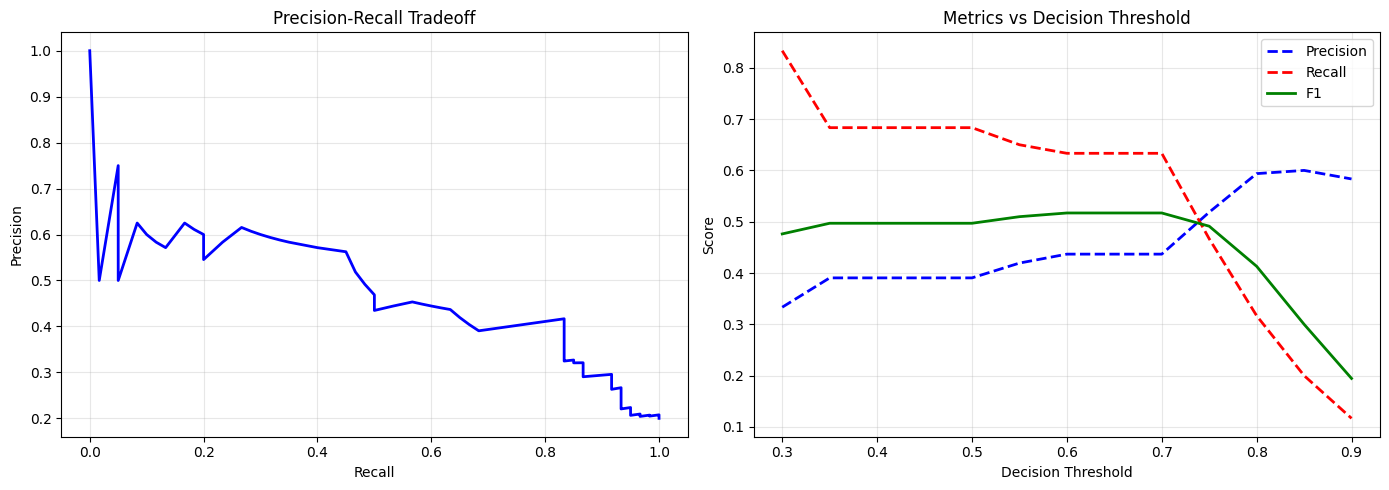

In [11]:
# Approach 1: Threshold tuning for precision-recall tradeoff
from sklearn.metrics import precision_recall_curve

prec_curve, rec_curve, thresholds = precision_recall_curve(y_test_bin, y_prob[:, 1])

# Find thresholds at various precision targets
precision_targets = [0.4, 0.5, 0.6, 0.7, 0.8]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
axes[0].plot(rec_curve, prec_curve, 'b-', linewidth=2)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Tradeoff')
axes[0].grid(True, alpha=0.3)

print("Precision-Recall at various thresholds:")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'N_pred_good':>12}")
threshold_results = []
for t in np.arange(0.3, 0.95, 0.05):
    y_pred_t = (y_prob[:, 1] >= t).astype(int)
    if y_pred_t.sum() == 0:
        continue
    p = precision_score(y_test_bin, y_pred_t, zero_division=0)
    r = recall_score(y_test_bin, y_pred_t, zero_division=0)
    f = f1_score(y_test_bin, y_pred_t, zero_division=0)
    n_good = y_pred_t.sum()
    print(f"{t:>10.2f} {p:>10.3f} {r:>10.3f} {f:>10.3f} {n_good:>12d}")
    threshold_results.append({'threshold': t, 'precision': p, 'recall': r, 'f1': f, 'n_pred_good': n_good})

tr_df = pd.DataFrame(threshold_results)

# Threshold vs metrics
axes[1].plot(tr_df['threshold'], tr_df['precision'], 'b--', label='Precision', linewidth=2)
axes[1].plot(tr_df['threshold'], tr_df['recall'], 'r--', label='Recall', linewidth=2)
axes[1].plot(tr_df['threshold'], tr_df['f1'], 'g-', label='F1', linewidth=2)
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Metrics vs Decision Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Approach 2: Confidence-based filtering
# Only consider predictions where TabPFN is very confident
confidence = np.max(y_prob, axis=1)  # max probability across classes

print("Confidence-based filtering (only predict 'good' when highly confident):")
print(f"{'Min Conf':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Coverage':>10}")

conf_results = []
for min_conf in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    # Predict good only if P(good) >= threshold AND confidence >= min_conf
    high_conf_mask = confidence >= min_conf
    if high_conf_mask.sum() == 0:
        continue
    
    # Among high-confidence predictions, measure precision
    y_pred_conf = y_pred.copy()
    y_pred_conf[~high_conf_mask] = 0  # default to 'bad' when uncertain
    
    p = precision_score(y_test_bin, y_pred_conf, zero_division=0)
    r = recall_score(y_test_bin, y_pred_conf, zero_division=0)
    f = f1_score(y_test_bin, y_pred_conf, zero_division=0)
    cov = high_conf_mask.mean()
    print(f"{min_conf:>10.2f} {p:>10.3f} {r:>10.3f} {f:>10.3f} {cov:>10.3f}")
    conf_results.append({'min_conf': min_conf, 'precision': p, 'recall': r, 'f1': f, 'coverage': cov})

Confidence-based filtering (only predict 'good' when highly confident):
  Min Conf  Precision     Recall         F1   Coverage
      0.50      0.390      0.683      0.497      1.000
      0.60      0.437      0.633      0.517      0.940
      0.70      0.437      0.633      0.517      0.790
      0.80      0.594      0.317      0.413      0.607
      0.90      0.583      0.117      0.194      0.520
      0.95      0.000      0.000      0.000      0.450


Per-substation performance:
  Sub   N_test   N_good     Prec   Recall       F1
    1       60       14    0.246    1.000    0.394
    3       48        4    0.444    1.000    0.615
    4       24        8    0.583    0.875    0.700
    5       90       17    0.444    0.235    0.308
    6       12        0    0.000    0.000    0.000
    8       24        7    0.583    1.000    0.737
   12       15        7    0.833    0.714    0.769


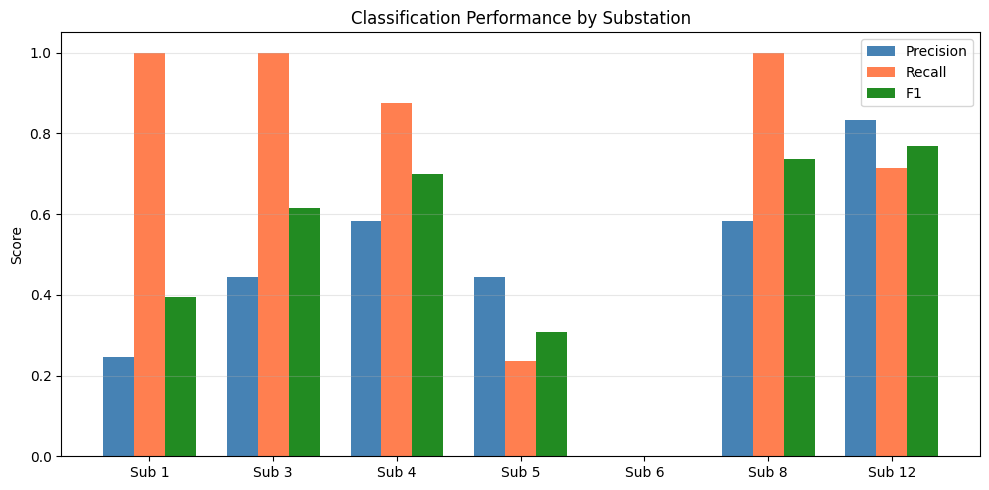

In [13]:
# Approach 3: Per-substation analysis
# Check if prediction quality varies by substation
df_test = df[test_mask].copy()
df_test['y_pred'] = y_pred
df_test['y_prob_good'] = y_prob[:, 1]

print("Per-substation performance:")
print(f"{'Sub':>5} {'N_test':>8} {'N_good':>8} {'Prec':>8} {'Recall':>8} {'F1':>8}")

sub_results = []
for sub_id in sorted(df_test['affected_sub'].unique()):
    mask = df_test['affected_sub'] == sub_id
    if mask.sum() < 10:
        continue
    yt = df_test.loc[mask, 'label_binary'].values
    yp = df_test.loc[mask, 'y_pred'].values
    n_good = yt.sum()
    p = precision_score(yt, yp, zero_division=0)
    r = recall_score(yt, yp, zero_division=0)
    f = f1_score(yt, yp, zero_division=0)
    print(f"{sub_id:>5} {mask.sum():>8} {n_good:>8} {p:>8.3f} {r:>8.3f} {f:>8.3f}")
    sub_results.append({'sub': sub_id, 'n_test': mask.sum(), 'n_good': n_good, 
                        'precision': p, 'recall': r, 'f1': f})

sub_df = pd.DataFrame(sub_results)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(sub_df))
w = 0.25
ax.bar(x - w, sub_df['precision'], w, label='Precision', color='steelblue')
ax.bar(x, sub_df['recall'], w, label='Recall', color='coral')
ax.bar(x + w, sub_df['f1'], w, label='F1', color='forestgreen')
ax.set_xticks(x)
ax.set_xticklabels([f"Sub {int(s)}" for s in sub_df['sub']])
ax.set_ylabel('Score')
ax.set_title('Classification Performance by Substation')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 4. Multi-label Classification

Instead of binary good/bad, classify actions into 4 quality levels:
- **0 (Bad)**: Action caused the simulation to fail
- **1 (Neutral)**: Survived but no improvement over do-nothing
- **2 (Good)**: Some improvement (either lower max_rho or higher reward)
- **3 (Excellent)**: Both lower max_rho AND higher reward

In [10]:
# Balance multi-label training data
rng_m = np.random.RandomState(42)
unique_labels = np.unique(y_train_multi)
min_count = min(np.sum(y_train_multi == l) for l in unique_labels)
MAX_PER_CLASS = min(min_count, MAX_TRAIN // len(unique_labels))

balanced_idx_multi = []
for l in unique_labels:
    idx_l = np.where(y_train_multi == l)[0]
    sampled = rng_m.choice(idx_l, min(MAX_PER_CLASS, len(idx_l)), replace=False)
    balanced_idx_multi.append(sampled)
balanced_idx_multi = np.concatenate(balanced_idx_multi)
rng_m.shuffle(balanced_idx_multi)

X_train_multi_bal = X_train[balanced_idx_multi]
y_train_multi_bal = y_train_multi[balanced_idx_multi]

print(f"Multi-label balanced training: {len(X_train_multi_bal)} samples")
print(f"Class distribution: {dict(zip(*np.unique(y_train_multi_bal, return_counts=True)))}")

# Feature selection
if X_train_multi_bal.shape[1] > MAX_FEATURES:
    variances_m = np.var(X_train_multi_bal, axis=0)
    top_feat_idx_m = np.argsort(variances_m)[-MAX_FEATURES:]
    X_train_multi_sub = X_train_multi_bal[:, top_feat_idx_m]
    X_test_multi_sub = X_test[:, top_feat_idx_m]
else:
    X_train_multi_sub = X_train_multi_bal
    X_test_multi_sub = X_test

# Train multi-class TabPFN
tabpfn_multi = TabPFNClassifier(device='cpu', ignore_pretraining_limits=True)
tabpfn_multi.fit(X_train_multi_sub, y_train_multi_bal)
y_pred_multi = tabpfn_multi.predict(X_test_multi_sub)
y_prob_multi = tabpfn_multi.predict_proba(X_test_multi_sub)

print(f"\nMulti-class results:")
print(classification_report(y_test_multi, y_pred_multi, 
                            target_names=['Bad(0)', 'Neutral(1)', 'Good(2)', 'Excellent(3)'],
                            zero_division=0))

Multi-label balanced training: 1000 samples
Class distribution: {np.int64(0): np.int64(250), np.int64(1): np.int64(250), np.int64(2): np.int64(250), np.int64(3): np.int64(250)}

Multi-class results:
              precision    recall  f1-score   support

      Bad(0)       0.52      0.47      0.50       112
  Neutral(1)       0.59      0.50      0.54       128
     Good(2)       0.28      0.79      0.42        28
Excellent(3)       0.58      0.22      0.32        32

    accuracy                           0.49       300
   macro avg       0.49      0.49      0.44       300
weighted avg       0.54      0.49      0.49       300



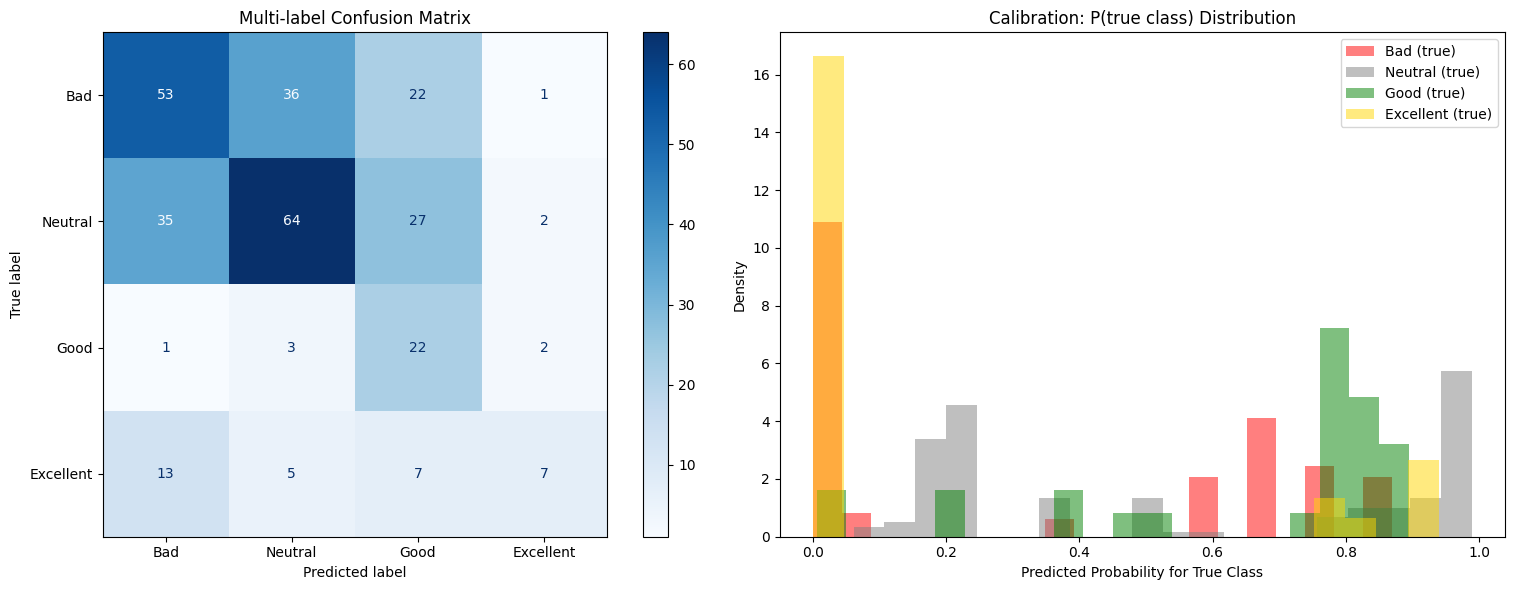

In [14]:
# Multi-label confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
cm = confusion_matrix(y_test_multi, y_pred_multi)
disp = ConfusionMatrixDisplay(cm, display_labels=['Bad', 'Neutral', 'Good', 'Excellent'])
disp.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Multi-label Confusion Matrix')

# Prediction probability distributions per class
for label, name, color in [(0, 'Bad', 'red'), (1, 'Neutral', 'gray'), 
                            (2, 'Good', 'green'), (3, 'Excellent', 'gold')]:
    mask = y_test_multi == label
    if mask.sum() > 0 and y_prob_multi.shape[1] > label:
        axes[1].hist(y_prob_multi[mask, label], bins=20, alpha=0.5, 
                     label=f'{name} (true)', color=color, density=True)

axes[1].set_xlabel('Predicted Probability for True Class')
axes[1].set_ylabel('Density')
axes[1].set_title('Calibration: P(true class) Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
# Compare binary vs multi-label: can multi-label improve precision?
# Map multi-label predictions back to binary: classes 2,3 -> 'good', classes 0,1 -> 'bad'
y_pred_multi_as_binary = (y_pred_multi >= 2).astype(int)
y_prob_multi_as_binary = y_prob_multi[:, 2:].sum(axis=1) if y_prob_multi.shape[1] >= 3 else y_prob_multi[:, -1]

print("Comparison: Binary vs Multi-label (mapped to binary)")
print(f"{'':>20} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")

p_bin = precision_score(y_test_bin, y_pred, zero_division=0)
r_bin = recall_score(y_test_bin, y_pred, zero_division=0)
f_bin = f1_score(y_test_bin, y_pred, zero_division=0)
auc_bin = roc_auc_score(y_test_bin, y_prob[:, 1])
print(f"{'Binary TabPFN':>20} {p_bin:>10.3f} {r_bin:>10.3f} {f_bin:>10.3f} {auc_bin:>10.3f}")

p_multi = precision_score(y_test_bin, y_pred_multi_as_binary, zero_division=0)
r_multi = recall_score(y_test_bin, y_pred_multi_as_binary, zero_division=0)
f_multi = f1_score(y_test_bin, y_pred_multi_as_binary, zero_division=0)
auc_multi = roc_auc_score(y_test_bin, y_prob_multi_as_binary)
print(f"{'Multi-label TabPFN':>20} {p_multi:>10.3f} {r_multi:>10.3f} {f_multi:>10.3f} {auc_multi:>10.3f}")

# Also show multi-label with high threshold on P(good+excellent)
for t in [0.6, 0.7, 0.8, 0.9]:
    y_pred_t = (y_prob_multi_as_binary >= t).astype(int)
    if y_pred_t.sum() == 0:
        continue
    p_t = precision_score(y_test_bin, y_pred_t, zero_division=0)
    r_t = recall_score(y_test_bin, y_pred_t, zero_division=0)
    f_t = f1_score(y_test_bin, y_pred_t, zero_division=0)
    print(f"{'Multi @' + str(t):>20} {p_t:>10.3f} {r_t:>10.3f} {f_t:>10.3f} {'':>10}")

Comparison: Binary vs Multi-label (mapped to binary)
                      Precision     Recall         F1        AUC
       Binary TabPFN      0.390      0.683      0.497      0.786
  Multi-label TabPFN      0.422      0.633      0.507      0.731
          Multi @0.6      0.436      0.567      0.493           
          Multi @0.7      0.436      0.567      0.493           
          Multi @0.8      0.421      0.400      0.410           
          Multi @0.9      0.714      0.167      0.270           


## 5. Summary

### Key Findings

**Features:**
- Our feature set covers all standard NTO categories from literature
- Feature ablation reveals which categories are most important for the classification task

**Precision Improvement:**
- Threshold tuning: can trade recall for precision (higher threshold → fewer but more reliable predictions)
- Confidence filtering: defaulting to "bad" when uncertain can improve precision
- Per-substation: performance varies — some substations are inherently easier to predict

**Multi-label:**
- Finer-grained labels (Bad/Neutral/Good/Excellent) provide richer action quality information
- When mapped back to binary, multi-label can potentially improve precision by separating neutral from bad